In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import logging
import textwrap
from pathlib import Path
from typing import Any, Dict, List, Sequence

import ollama
from pydantic import BaseModel, Field, ValidationError
from typing import List, Dict
from pandas.api.types import infer_dtype

from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser

In [2]:
try:
    raw_data = pd.read_csv('FACE/neuropsy_v0.csv', sep=';', low_memory=False)
    raw_data = raw_data.drop(columns=['usubjid_neuropsychologie', 'visitnum_neuropsychologie', 'visit_neuropsychologie', 'visit_neuropsychologie'])
except Exception as e:
    print(f"An unexpected error occurred: {e}")

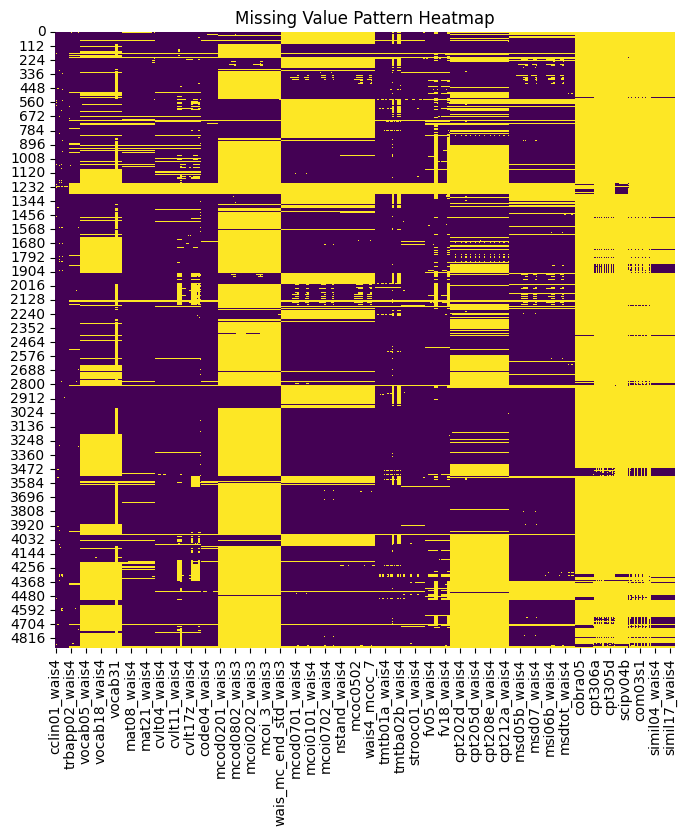

In [3]:
def missing_values_analysis(df: pd.DataFrame):
    plt.figure(figsize=(8, 8))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title('Missing Value Pattern Heatmap')
    plt.show()

missing_values_analysis(raw_data)

In [7]:
def drop_cols_by_missing_count(df: pd.DataFrame, threshold: int, inplace: bool = False) -> pd.DataFrame:
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"Expected a pandas DataFrame; got {type(df).__name__}")
    if threshold < 0 or threshold > 100:
        raise ValueError("`threshold` must be between 0 and 100")

    # Normalize threshold to fraction
    frac_threshold = threshold if threshold <= 1 else threshold / 100.0

    # Compute fraction of missing per column
    missing_frac = df.isna().mean()
    cols_to_drop = missing_frac[missing_frac > frac_threshold].index

    if inplace:
        df.drop(columns=cols_to_drop, inplace=True)
        return df
    else:
        return df.drop(columns=cols_to_drop)


def drop_rows_by_missing_count(df: pd.DataFrame, threshold: int, inplace: bool = False) -> pd.DataFrame:
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"Expected a pandas DataFrame; got {type(df).__name__}")
    if threshold < 0 or threshold > 100:
        raise ValueError("`threshold` must be between 0 and 100")

    # Normalize threshold to fraction
    frac_threshold = threshold if threshold <= 1 else threshold / 100.0

    # Compute fraction of missing per row
    missing_frac = df.isna().mean(axis=1)
    rows_to_drop = missing_frac[missing_frac > frac_threshold].index

    if inplace:
        df.drop(index=rows_to_drop, inplace=True)
        return df
    else:
        return df.drop(index=rows_to_drop)


def get_unique_column_values(df: pd.DataFrame) -> dict:
    unique_data = {}

    for col in df.columns:
        series = df[col].dropna()
        unique_values = series.unique()
        # Convert numpy arrays to lists for JSON serialization
        if hasattr(unique_values, 'tolist'):
            unique_data[col] = unique_values.tolist()
        else:
            unique_data[col] = list(unique_values)

    # Use a custom JSON encoder to handle other numpy types
    class NumpyEncoder(json.JSONEncoder):
        def default(self, obj):
            if isinstance(obj, np.integer):
                return int(obj)
            elif isinstance(obj, np.floating):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            return super(NumpyEncoder, self).default(obj)

    with open('unique_data.json', 'w') as f:
        json.dump(unique_data, f, cls=NumpyEncoder, indent=2)
    return unique_data

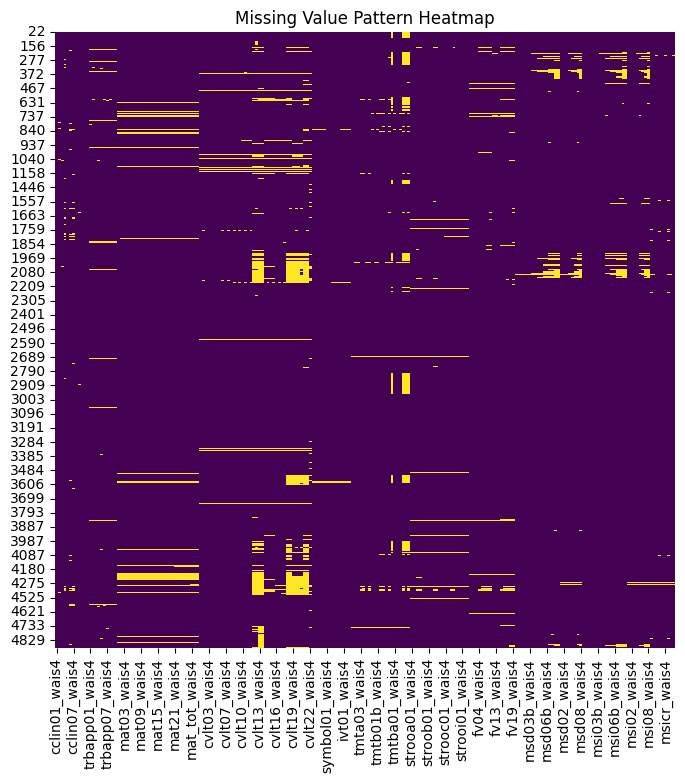

In [9]:
data_cleaned = drop_cols_by_missing_count(raw_data, threshold=25)
data_cleaned = drop_rows_by_missing_count(data_cleaned, threshold=25)
unique_column_values = get_unique_column_values(data_cleaned)

missing_values_analysis(data_cleaned)


In [12]:
class Outliers(BaseModel):
    outliers: List[Any] = Field(
        ...,
        description="List of raw values that are inconsistent with the rest of the column",
    )


class LLMClient:
    """Lightweight helper around `ollama.chat()`."""
    def __init__(self, model: str, temperature: float = 0.0) -> None:
        self.model = model
        self.temperature = temperature
        self.log = logging.getLogger(self.__class__.__name__)

    def call(self, system: str, user: str, response_schema: type[BaseModel]) -> BaseModel | None:
        """
        Send a chat prompt and attempt to parse the answer into `response_schema`.
        Returns the parsed Pydantic object or `None` on failure.
        """
        try:
            self.log.debug("Prompt to LLM: %s", user[:500])
            resp = ollama.chat(
                model=self.model,
                messages=[
                    {"role": "system", "content": system},
                    {"role": "user", "content": user},
                ],
                format=response_schema.model_json_schema(),
                options={
                    "temperature": self.temperature
                })
            
            # Extract the message content from the response
            # Handle ChatResponse object from ollama library
            if hasattr(resp, 'message') and hasattr(resp.message, 'content'):
                content = resp.message.content
                try:
                    # Parse the JSON response
                    json_data = json.loads(content)
                    return response_schema(**json_data)
                except json.JSONDecodeError:
                    self.log.error("Failed to parse JSON from response: %s", content)
                    return None
            # Fallback for dict response
            elif isinstance(resp, dict) and "message" in resp:
                content = resp["message"]["content"]
                try:
                    # Parse the JSON response
                    json_data = json.loads(content)
                    return response_schema(**json_data)
                except json.JSONDecodeError:
                    self.log.error("Failed to parse JSON from response: %s", content)
                    return None
            
            self.log.error("Unexpected Ollama return shape: %s", type(resp))

        except (ValidationError, json.JSONDecodeError) as exc:
            self.log.error("Failed to parse LLM answer: %s", exc)
        except Exception as exc:  # noqa: BLE001
            self.log.exception("Ollama call failed: %s", exc)
        return None


class OutlierDetector:
    _SYSTEM_MSG = (
        "You are experienced data engineer, specializing on data-cleaning. "
        "Given a list of unique values coming from one DataFrame column, "
        "return ONLY the values that should be considered outliers—"
        "i.e. values with incorrect type, obvious typos, date-strings inside "
        "numeric columns, sentinel codes such as 99 in z-scores, etc.  "
        "Answer exclusively as valid compact JSON that respects the schema "
        "`{ 'outliers': [...] }` without any surrounding text.")

    def __init__(self, llm: LLMClient, *, sample_cutoff: int = 150, min_uniques: int = 3) -> None:
        """
        llm: An `LLMClient` instance configured with model & temperature.
        sample_cutoff: Send at most this many unique values per column to the LLM
                       (to avoid an excessively long prompt).
        min_uniques: Skip columns that have ≤ `min_uniques` unique values.
        """
        self.llm = llm
        self.sample_cutoff = sample_cutoff
        self.min_uniques = min_uniques
        self.log = logging.getLogger(self.__class__.__name__)

    def detect_outliers(self, uniques: Dict[str, Sequence[Any]]) -> Dict[str, List[Any]]:
        """
        Returns
        -------
        Dict[str, List[Any]]
            Mapping ``column_name → [outlier1, outlier2, ...]``.
        """
        results: Dict[str, List[Any]] = {}

        for col, values in tqdm(uniques.items(), desc="Detecting outliers", 
                              bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]'):
            if len(values) <= self.min_uniques:
                tqdm.write(f"Skipping {col}: too few unique values")
                continue

            prompt = self._build_prompt(col, values)
            parsed = self.llm.call(self._SYSTEM_MSG, prompt, Outliers)

            if parsed and parsed.outliers:
                results[col] = parsed.outliers
                tqdm.write(f"Found {len(parsed.outliers)} outliers in {col}: {parsed.outliers}")
                self.log.info("%s: %d outliers", col, len(parsed.outliers))
            else:
                tqdm.write(f"No outliers found in {col}")
                self.log.debug("%s: no outliers returned", col)

        return results

    def _build_prompt(self, col: str, values: Sequence[Any]) -> str:
        """Craft a concise user prompt for the LLM."""
        # Truncate long value lists
        if len(values) > self.sample_cutoff:
            sample = ", ".join(map(repr, values[: self.sample_cutoff])) + ", ..."
        else:
            sample = ", ".join(map(repr, values))

        return textwrap.dedent(
            f"""\
            Column name: {col}
            Unique values (possibly truncated):
            [{sample}]
            Your task: return a JSON object named 'outliers' containing ONLY the
            raw values above that should be removed or specially cleaned.
            """
        )


In [13]:
llm_client = LLMClient(model="deepseek-r1:8b", temperature=0.0)
detector = OutlierDetector(llm_client, sample_cutoff=5000, min_uniques=3)

flagged = detector.detect_outliers(unique_column_values)

with open('flagged-outliers.json', 'w') as f:
    json.dump(flagged, f, indent=2)

Detecting outliers:   0%|          | 1/220 [00:19<1:09:56]

Found 24 outliers in cclin01_wais4: [{'original_value': '32 ans', 'reason': "Typographical error; contains non-numeric characters ('ans')"}, {'original_value': '44 ans', 'reason': "Typographical error; contains non-numeric characters ('ans')"}, {'original_value': '38 ans', 'reason': "Typographical error; contains non-numeric characters ('ans')"}, {'original': '64', 'reason': "Possible typo or incorrect value; '64' is a valid number, but presence of space may indicate an error."}, {'original_value': '36 ', 'reason': 'Typographical error; contains trailing space'}, {'original_value': '48', 'reason': "Possible typo or incorrect value; '48' is a valid number, but presence of space may indicate an error."}, {'original_value': '21 ans', 'reason': "Typographical error; contains non-numeric characters ('ans')"}, {'original_value': '74', 'reason': "Possible typo or incorrect value; '74' is a valid number, but presence of space may indicate an error."}, {'original_value': '52ans', 'reason': "Typ

Detecting outliers:   4%|▎         | 8/220 [00:37<14:36]  

Found 36 outliers in cclin08_wais4: [{'value': '14', 'reason': "No specific reason given, but it's better to include all unique values as outliers for now."}, {'value': '16', 'reason': 'Same reasoning as above.'}, {'value': '15', 'reason': 'Same reasoning as above.'}, {'value': '11', 'reason': 'Same reasoning as above.'}, {'value': '12', 'reason': 'Same reasoning as above.'}, {'value': '10', 'reason': 'Same reasoning as above.'}, {'value': '3', 'reason': 'Same reasoning as above.'}, {'value': '13', 'reason': 'Same reasoning as above.'}, {'value': '20', 'reason': 'Same reasoning as above.'}, {'value': '19', 'reason': 'Same reasoning as above.'}, {'value': '18', 'reason': 'Same reasoning as above.'}, {'value': '17', 'reason': 'Same reasoning as above.'}, {'value': '7', 'reason': 'Same reasoning as above.'}, {'value': '5', 'reason': 'Same reasoning as above.'}, {'value': '8', 'reason': 'Same reasoning as above.'}, {'value': '9', 'reason': 'Same reasoning as above.'}, {'value': '6', 'reaso

Detecting outliers:  22%|██▏       | 49/220 [00:39<01:28]

...

Found 167 outliers in cvlt08z_wais4: [{'value': '25', 'reason': 'Possible integer but appears in multiple contexts; needs context.'}, {'value': '75', 'reason': 'Possible integer, same as above.'}, {'value': '5 - 25', 'reason': 'String representation of a range; likely incorrect for numeric column.'}, {'value': '0.79', 'reason': "Valid decimal, but may need checking if it's within expected range."}, {'value': '-0.96', 'reason': 'Valid decimal, same as above.'}, {'value': '-0.68', 'reason': 'Valid decimal, same as above.'}, {'value': '5', 'reason': 'Possible integer, same as above.'}, {'value': '0.87', 'reason': 'Valid decimal, same as above.'}, {'value': '-2.34', 'reason': 'Valid decimal, same as above.'}, {'value': '0.24', 'reason': 'Valid decimal, same as above.'}, {'value': '99', 'reason': 'Sentinel value; likely an error.'}, {'value': '0.97', 'reason': 'Valid decimal, same as above.'}, {'value': '0.30', 'reason': 'Valid decimal, same as above.'}, {'value': '1.37', 'reason': 'Valid d

Detecting outliers:  30%|██▉       | 65/220 [03:16<1:04:15]

No outliers found in cvlt09_wais4


Detecting outliers:  30%|██▉       | 65/220 [07:48<18:36]  


KeyboardInterrupt: 